In [1]:
import glob #importing glob library
import matplotlib.pyplot as plt #Need for plotting at the end
import numpy as np #numpi

In [2]:
import astropy
import astropy.units as u
from astropy.utils.data import download_file
from astropy.io import fits
from astropy.utils import data
from astropy.wcs import wcs #everything above is for reading FIT/FITS
from astropy.visualization import (AsinhStretch, LogStretch, 
                                  PercentileInterval, ImageNormalize, simple_norm, ZScaleInterval) #tools for visualizing large range of fits data

In [3]:
from astropy.nddata import CCDData
import pandas as pd
from astropy.coordinates import SkyCoord #don't remeber if any of this is needed

import ipywidgets as widgets
!pip install ipycanvas
from IPython.display import display #widgets/canvas is how the image gets displayed/interacted with

In [4]:
!pip install astropy astroalign numpy
import astroalign as aa #JJ said we would make our own huzzah

In [5]:
from ipycanvas import Canvas
from PIL import Image
from PIL import ImageTk
from tkinter import * #more canvas functions we will need

In [6]:
import astropy.units as u
from astropy.utils import data
!pip install spectral-cube
from spectral_cube import SpectralCube #turned out to be not needed but might need in the future

In [41]:
!pip install photutils
from photutils.aperture import CircularAperture
from photutils.aperture import aperture_photometry

In [8]:
image_data = fits.open("D:/EB NSVS01031772 Usable Files/2022 EB Files/03-22-2019/pipelineout/test-0001_out.fit")[0].data #reads FITS data from file
interval = ZScaleInterval(n_samples=1000, contrast=0.25) #interval is created by sampling the file
vmin,vmax = interval.get_limits(image_data) #creates min and max value based on defined interval

#This process is necessary because python will just assign the highest value to white and the lowest to black, so most of the details in unedited 
#data will become black due to the insanely high counts for a few very bright stars

if vmax <= vmin or (vmax - vmin) < 1e-5: #safeguard - if the interval is way to big it will just reset to 99%
    interval = PercentileInterval(99)
    vmin, vmax = interval.get_limits(image_data) #the top and bottom 0.5% will be cut off

data_range = vmax - vmin #defining range of data that will be displayed
vmin_adjusted = vmin +(data_range * 0.18) #cutting off more from the bottom depending on how big the range is

clipped_image_data = np.clip(image_data, vmin_adjusted, vmax) #clipping off edges of data based on limits
normalized = (clipped_image_data - vmin_adjusted) / (vmax - vmin_adjusted) #normalization fromula usually done by .plt
canvas_image = (normalized * 255).astype(np.uint8) #this is needed to turn FITS data into color values that canvas can read

In [34]:
from PIL import Image

root = Tk()
root.title("Analyze Cube")
root.geometry('1350x1050') #creating basic features of the canvas

pil_img = Image.fromarray(canvas_image, mode='L') #turns array into canvas image, L means greyscale for some reason
tk_img = ImageTk.PhotoImage(image=pil_img, master=root) #creating image while referring back to previously defined properties

hbar = Scrollbar(root, orient=HORIZONTAL)
hbar.pack(side=BOTTOM, fill=X)
vbar = Scrollbar(root, orient=VERTICAL)
vbar.pack(side=RIGHT, fill=Y) #if image is bigger than moniter than you have problem, thus we make it small in line three and give it scroll bars here

canvas = Canvas(root, width=1250, height=950, #smaller than defined before to make room for scroll bars
                scrollregion=(0, 0, canvas_image.shape[1], canvas_image.shape[0]),
                xscrollcommand=hbar.set, yscrollcommand=vbar.set) #just setting up the function of scrolling
canvas.pack(side=LEFT, expand=True, fill=BOTH)

hbar.config(command=canvas.xview)
vbar.config(command=canvas.yview)
canvas.create_image(0, 0, anchor="nw", image=tk_img) #actually puting the image on screen

chosen_x = [] #defining variables for coordinates
chosen_y = []

def select_pixels(event):
    pixel_x = int(canvas.canvasx(event.x)) #these adjust for the fact that you have scrolled which would otherwise not be accounted for
    pixel_y = int(canvas.canvasy(event.y))
    height, width = canvas_image.shape #pulling the dimensions to account for clicking outside of the image
    
    if 0 <= pixel_x < width and 0 <= pixel_y < height: #this is only true if your mouse is within the image so there's no errors when you click off
        chosen_x.append(pixel_x)
        chosen_y.append(pixel_y) #assigns your mouse coordinates to the previously defined array. Will override everytime you click

aperture_info_x = []
aperture_info_y = []

star_center_x = []
star_center_y = []

star_radii = []

star_order = ['red', 'yellow', 'lime', 'blue', 'magenta', 'red', 'yellow', 'lime', 'blue', 'magenta', 'red', 'yellow', 'lime', 'blue', 'magenta']

def aperture_create(event):      
    
    selected_x = int(canvas.canvasx(event.x))
    selected_y = int(canvas.canvasy(event.y))
    height, width = canvas_image.shape

    if 0 <= selected_x < width and 0 <= selected_y < height:
        aperture_info_x.append(selected_x)
        aperture_info_y.append(selected_y)

        if len(aperture_info_x) % 2 == 0 and len(aperture_info_x) != 0:
            radius = np.sqrt((aperture_info_x[-1] - aperture_info_x[-2]) ** 2 +(aperture_info_y[-1] - aperture_info_y[-2]) ** 2)
            color = f'{star_order[int(len(aperture_info_x)/2-1)]}'
            canvas.create_oval(aperture_info_x[-2] - radius, aperture_info_y[-2] - radius, aperture_info_x[-2] + radius, aperture_info_y[-2] + radius, fill="", outline=color, width=2, tags="aperture")
            canvas.create_oval(aperture_info_x[-2] - 5 - 1.2 * radius, aperture_info_y[-2] - 5 - 1.2 * radius, aperture_info_x[-2] + 5 + 1.2 * radius, aperture_info_y[-2] + 5 + 1.2 * radius, fill="", outline=color, width=2, tags="aperture")
            canvas.create_oval(aperture_info_x[-2] - 7 - 1.5 * radius, aperture_info_y[-2] - 7 - 1.5 * radius, aperture_info_x[-2] + 7 + 1.5 * radius, aperture_info_y[-2] + 7 + 1.5 * radius, fill="", outline=color, width=2, tags="aperture")
            star_radii.append(radius)
        if len(aperture_info_x) % 2 != 0:
            star_center_x.append(selected_x)
            star_center_y.append(selected_y)

#canvas.create_oval(x0, y0, x1, y1, fill="red", outline="white", width=2, tags="my_circle")

canvas.bind('<1>', select_pixels) #binds function to click, which here is <1>

canvas.bind('<3>', aperture_create)

root.protocol("WM_DELETE_WINDOW", lambda: (root.quit(), root.destroy())) #ends cell rutime when you close out of the image
root.mainloop()

In [70]:
hdu_list = fits.open("C:/Users/Astroadmin/Downloads/cube_norm (1).fits") #placeholder file - it should take from the created cube when the code gets integrated
data = hdu_list[0].data #pulls cube data from HDU

apertures = [[] for _ in range(len(star_radii))]

if len(aperture_info_x) % 2 != 0:
    print('aperture data incomplete')
if len(aperture_info_x) % 2 == 0:
    for i in range(len(star_radii)):
        radius = star_radii[i]
        center_x = star_center_x[i]
        center_y = star_center_y[i]
        position = [(center_x, center_y)]
        aperture = CircularAperture(position, r=radius)
        for j in range(len(data[:, 10, 10])):
            slice_data = data[j, :, :]
            aperture_calculation = aperture_photometry(slice_data, aperture)
            sum_value = aperture_calculation['aperture_sum'][0]
            apertures[i].append(sum_value)
print(apertures)
      

[[np.float64(25.280004157936453), np.float64(25.23989299413594), np.float64(25.527002697237386), np.float64(25.624451260675905), np.float64(25.59239759811659), np.float64(25.608250562729587), np.float64(25.508600025391075), np.float64(25.40945461490884), np.float64(25.349673266639144), np.float64(25.423284736029796), np.float64(25.440622120282143), np.float64(25.43164783247629), np.float64(25.230250773875113), np.float64(24.998945298019052), np.float64(24.95731712296074)], [np.float64(137.21494565478275), np.float64(136.99152118964452), np.float64(138.2429494156627), np.float64(138.863461164991), np.float64(138.9068639739951), np.float64(138.86326637628923), np.float64(138.06049728241737), np.float64(137.72680280629288), np.float64(137.27915377378594), np.float64(137.67250280457134), np.float64(137.8606921780933), np.float64(137.74248369618988), np.float64(136.68598738715238), np.float64(135.46605403504304), np.float64(135.1936485962591)], [np.float64(88.54570666650653), np.float64(88.

In [44]:
hdu_list = fits.open("C:/Users/Astroadmin/Downloads/cube_norm (1).fits") #placeholder file - it should take from the created cube when the code gets integrated
data = hdu_list[0].data #pulls cube data from HDU

aperture_test = data[2, :, :]
print(len(data[:, 10, 10]))

15


In [17]:
print(chosen_x) #proof of concept
print(chosen_y)

[624, 683, 595]
[516, 572, 664]


In [39]:
print(aperture_info_x)
print(aperture_info_y)

[645, 658, 677, 708, 818, 843]
[461, 464, 697, 697, 570, 569]


In [38]:
print(star_center_x)
print(star_center_y)

[645, 677, 818]
[461, 697, 570]


In [37]:
print(star_radii)

[np.float64(13.341664064126334), np.float64(31.0), np.float64(25.019992006393608)]


In [21]:
hdu_list = fits.open("C:/Users/Astroadmin/Downloads/cube_norm (1).fits") #placeholder file - it should take from the created cube when the code gets integrated
data = hdu_list[0].data #pulls cube data from HDU

Poisson_boolian = [] #array to store conclusion for every click

def Poisson_Check(data):
    for i in range(len(chosen_x)):
        intensity_sequence = (data[:, chosen_x[i], chosen_y[i]]) #for simplicity the row of values is stored here
        variance = sum([((fn-np.average(intensity_sequence))**2) for n, fn in enumerate(intensity_sequence)]) / (len([j for j in intensity_sequence])) #variance formula, fn is the value whereas n is the place of the value
        if np.average(intensity_sequence) >= variance: #Poisson distribution is technically only true if these are equal, but for our puposes it is better if variance is less than average
            Poisson_boolian.append(f'Click {i+1} follows Poisson distribution - average: {np.average(intensity_sequence)} >= variance: {variance}') #want to display numbers to give context for conclusion
        else:
            Poisson_boolian.append(f'Click {i+1} does not follow Poisson distribution - average: {np.average(intensity_sequence)} <= variance: {variance}')
    return Poisson_boolian

Poisson_Check(data)

['Click 1 follows Poisson distribution - average: 0.0455724373459816 >= variance: 6.944692927390861e-07',
 'Click 2 follows Poisson distribution - average: 0.04550326615571976 >= variance: 6.620003318857925e-07',
 'Click 3 follows Poisson distribution - average: 0.04527104273438454 >= variance: 3.635647374267137e-07']

[0.04495256 0.04488336 0.04534992 0.04624259 0.04807588 0.04585744
 0.04551038 0.04523051 0.04548423 0.04509548 0.04517323 0.04480398
 0.04576655 0.0464654  0.04469499]
[0.04548141 0.04461898 0.04656298 0.04660022 0.04591464 0.04612179
 0.04507502 0.04689419 0.04500218 0.04557753 0.04570194 0.04508401
 0.04547149 0.04377873 0.04466393]
[0.04526365 0.04531882 0.04612753 0.04635144 0.04579025 0.04442682
 0.04479515 0.04425095 0.04529763 0.04579524 0.04517323 0.04592408
 0.04502112 0.04467946 0.04485029]


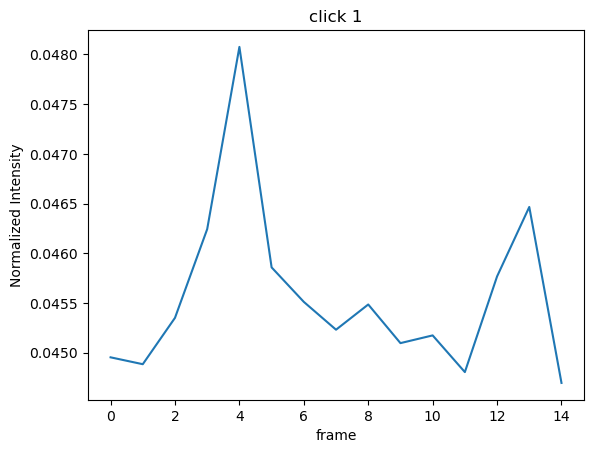

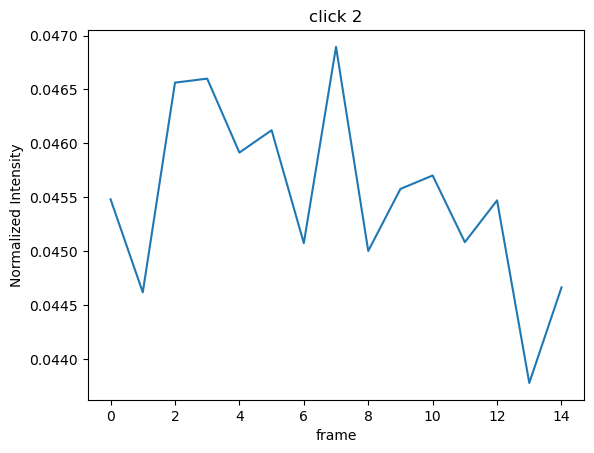

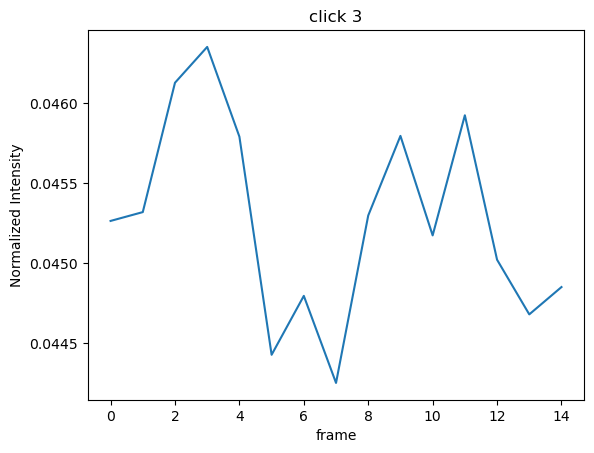

In [20]:
hdu_list = fits.open('C:/Users/Astroadmin/Downloads/cube_norm (1).fits') #placeholder file - it should take from the created cube when the code gets integrated
data = hdu_list[0].data #pulls cube data from HDU

for i in range(len(chosen_x)):
    print(data[:, chosen_x[i], chosen_y[i]]) #takes a slice for all frames/FIT files at the coordinates you clicked
    graph = data[:, chosen_x[i], chosen_y[i]] 
    plt.figure()
    plt.plot(graph) #plot dot plot
    plt.ylabel('Normalized Intensity')
    plt.xlabel('frame')
    plt.title(f'click {i+1}')
    plt.show

In [ ]:
#img_aligned, footprint = aa.register(img, img_rotated, detection_sigma=3.0)
#img_aligned names the aligned image
#footprint is just what image_aligned will be
#aa.register is the acutal function that aligns
#aa.register(image that you match to, image that needs to be shifted, idk about detection I think that specifies how specific the matching algorithm works.)
#turns out we'll be doing this ourselves but I'll leave this here regardless